# Kalman Filter Tutorial

This notebook explains what a Kalman filter is, why it works, how to implement one from scratch with `numpy`, and how to use it on two small examples.

The examples are intentionally small so the mechanics are visible:

1. Estimate a slowly changing scalar value from noisy measurements.
2. Track 1D position and velocity when only noisy position measurements are observed.

## 1. What is a Kalman filter?

A Kalman filter is a recursive estimator for a hidden state that changes over time. It combines two imperfect sources of information:

- A **process model**: how we think the state evolves.
- A **measurement model**: how sensors observe the state.

The filter alternates between:

1. **Prediction**: use the model to predict the next state.
2. **Update**: correct that prediction using the newest measurement.

The classical Kalman filter assumes the dynamics and measurement equations are linear, and the uncertainty is Gaussian. Under those assumptions it is the optimal minimum-variance estimator.

## 2. The model

The hidden state is represented by a vector $x_t$. For example, in a tracking problem:

$$
x_t = \begin{bmatrix}\text{position}_t \\ \text{velocity}_t\end{bmatrix}
$$

The Kalman filter uses two equations.

### State transition

$$
x_t = F x_{t-1} + B u_t + w_t
$$

- $F$ maps the previous state to the next state.
- $u_t$ is an optional control input.
- $B$ maps the control input into state space.
- $w_t \sim \mathcal{N}(0, Q)$ is process noise.
- $Q$ is the process noise covariance.

### Measurement

$$
z_t = H x_t + v_t
$$

- $z_t$ is the observed measurement.
- $H$ maps state space into measurement space.
- $v_t \sim \mathcal{N}(0, R)$ is measurement noise.
- $R$ is the measurement noise covariance.

## 3. The algorithm

The filter tracks two things:

- $x$: the current best state estimate.
- $P$: the covariance matrix describing uncertainty in that estimate.

### Prediction step

$$
\hat{x}^{-}_t = F\hat{x}_{t-1} + B u_t
$$

$$
P^{-}_t = F P_{t-1} F^T + Q
$$

The superscript $-$ means "before seeing the new measurement."

### Update step

Innovation, also called residual:

$$
y_t = z_t - H\hat{x}^{-}_t
$$

Innovation covariance:

$$
S_t = H P^{-}_t H^T + R
$$

Kalman gain:

$$
K_t = P^{-}_t H^T S_t^{-1}
$$

Corrected state estimate:

$$
\hat{x}_t = \hat{x}^{-}_t + K_t y_t
$$

Corrected covariance:

$$
P_t = (I - K_t H)P^{-}_t
$$

Intuition: the Kalman gain decides how much to trust the measurement relative to the prediction. If measurement noise $R$ is large, the filter trusts the model more. If state uncertainty $P$ is large, the filter trusts the measurement more.

In [1]:
import numpy as np

np.set_printoptions(precision=3, suppress=True)

## 4. A minimal Kalman filter implementation

The class below implements the standard linear Kalman filter. It supports optional control inputs, but the examples in this notebook do not need controls.

In [2]:
class KalmanFilter:
    def __init__(self, x, P, F, H, Q, R, B=None):
        self.x = np.asarray(x, dtype=float)
        self.P = np.asarray(P, dtype=float)
        self.F = np.asarray(F, dtype=float)
        self.H = np.asarray(H, dtype=float)
        self.Q = np.asarray(Q, dtype=float)
        self.R = np.asarray(R, dtype=float)
        self.B = None if B is None else np.asarray(B, dtype=float)

        self.n = self.x.shape[0]
        self.I = np.eye(self.n)

    def predict(self, u=None):
        if self.B is not None and u is not None:
            self.x = self.F @ self.x + self.B @ np.asarray(u, dtype=float)
        else:
            self.x = self.F @ self.x

        self.P = self.F @ self.P @ self.F.T + self.Q
        self.P = 0.5 * (self.P + self.P.T)  # reduce tiny numerical asymmetry
        return self.x, self.P

    def update(self, z):
        z = np.asarray(z, dtype=float)

        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = np.linalg.solve(S.T, (self.P @ self.H.T).T).T

        self.x = self.x + K @ y
        self.P = (self.I - K @ self.H) @ self.P
        self.P = 0.5 * (self.P + self.P.T)

        return self.x, self.P, K, y

## 5. Example 1: estimate a noisy scalar signal

Suppose the true value is almost constant, but our measurements are noisy. This could represent a temperature sensor, a slowly drifting baseline, or any scalar quantity observed with noise.

State:

$$
x_t = \text{true value at time } t
$$

Model:

$$
x_t = x_{t-1} + w_t
$$

Measurement:

$$
z_t = x_t + v_t
$$

In [3]:
rng = np.random.default_rng(7)

n_steps = 20
true_value = 10.0
measurement_std = 2.0
measurements = true_value + rng.normal(0, measurement_std, size=n_steps)

kf_scalar = KalmanFilter(
    x=np.array([0.0]),          # initial estimate
    P=np.array([[25.0]]),       # high initial uncertainty
    F=np.array([[1.0]]),        # value stays roughly the same
    H=np.array([[1.0]]),        # sensor observes the value directly
    Q=np.array([[0.01]]),       # small process noise
    R=np.array([[measurement_std**2]]),
)

scalar_estimates = []
scalar_gains = []

for z in measurements:
    kf_scalar.predict()
    x, P, K, y = kf_scalar.update(np.array([z]))
    scalar_estimates.append(x[0])
    scalar_gains.append(K[0, 0])

print("step | measurement | estimate | kalman gain")
print("-----+-------------+----------+------------")
for i, (z, estimate, gain) in enumerate(zip(measurements, scalar_estimates, scalar_gains), start=1):
    print(f"{i:>4} | {z:>11.3f} | {estimate:>8.3f} | {gain:>10.3f}")

step | measurement | estimate | kalman gain
-----+-------------+----------+------------
   1 |      10.002 |    8.623 |      0.862
   2 |      10.597 |    9.539 |      0.464
   3 |       9.452 |    9.511 |      0.318
   4 |       8.219 |    9.197 |      0.243
   5 |       9.091 |    9.176 |      0.197
   6 |       8.017 |    8.984 |      0.166
   7 |      10.120 |    9.148 |      0.144
   8 |      12.680 |    9.600 |      0.128
   9 |       9.016 |    9.533 |      0.115
  10 |       8.759 |    9.451 |      0.106
  11 |      10.980 |    9.600 |      0.098
  12 |      10.714 |    9.701 |      0.091
  13 |      10.211 |    9.745 |      0.085
  14 |       8.139 |    9.615 |      0.081
  15 |       9.941 |    9.640 |      0.077
  16 |      11.391 |    9.769 |      0.074
  17 |       7.312 |    9.595 |      0.071
  18 |       9.085 |    9.560 |      0.068
  19 |       6.198 |    9.338 |      0.066
  20 |       7.421 |    9.215 |      0.064


Notice how the estimate starts by moving strongly toward the measurements. As the covariance $P$ shrinks, the Kalman gain decreases and the filter becomes less reactive to each noisy measurement.

## 6. Example 2: track position and velocity

Now suppose an object moves along a line with roughly constant velocity. We measure position, but we do not directly measure velocity.

State:

$$
x_t = \begin{bmatrix}\text{position}_t \\ \text{velocity}_t\end{bmatrix}
$$

With time step $\Delta t$, a constant-velocity model is:

$$
F = \begin{bmatrix}1 & \Delta t \\ 0 & 1\end{bmatrix}
$$

Because the sensor only observes position:

$$
H = \begin{bmatrix}1 & 0\end{bmatrix}
$$

In [4]:
rng = np.random.default_rng(3)

dt = 1.0
n_steps = 30

true_initial_position = 0.0
true_velocity = 1.2
measurement_std = 3.0

times = np.arange(n_steps)
true_positions = true_initial_position + true_velocity * times
measurements = true_positions + rng.normal(0, measurement_std, size=n_steps)

F = np.array([[1.0, dt],
              [0.0, 1.0]])
H = np.array([[1.0, 0.0]])

# Small process noise: the object mostly follows constant velocity.
Q = np.array([[0.05, 0.0],
              [0.0, 0.05]])

R = np.array([[measurement_std**2]])

kf_tracker = KalmanFilter(
    x=np.array([0.0, 0.0]),
    P=np.array([[100.0, 0.0],
                [0.0, 100.0]]),
    F=F,
    H=H,
    Q=Q,
    R=R,
)

position_estimates = []
velocity_estimates = []

for z in measurements:
    kf_tracker.predict()
    x, P, K, y = kf_tracker.update(np.array([z]))
    position_estimates.append(x[0])
    velocity_estimates.append(x[1])

print(" step | true pos | measured | est pos | est vel")
print("------+----------+----------+---------+--------")
for i in range(0, n_steps, 3):
    print(
        f"{i:>5} | {true_positions[i]:>8.3f} | {measurements[i]:>8.3f} | "
        f"{position_estimates[i]:>7.3f} | {velocity_estimates[i]:>6.3f}"
    )

print("\nFinal state estimate:")
print(f"position = {position_estimates[-1]:.3f}")
print(f"velocity = {velocity_estimates[-1]:.3f}")
print(f"true velocity = {true_velocity:.3f}")

 step | true pos | measured | est pos | est vel
------+----------+----------+---------+--------
    0 |    0.000 |    6.123 |   5.859 |  2.929
    3 |    3.600 |    1.897 |   1.012 | -0.165
    6 |    7.200 |    1.140 |   3.085 |  0.302
    9 |   10.800 |   20.769 |  12.243 |  1.770
   12 |   14.400 |   13.556 |  14.934 |  1.353
   15 |   18.000 |   16.828 |  16.685 |  1.019
   18 |   21.600 |   24.473 |  22.128 |  1.401
   21 |   25.200 |   29.837 |  26.984 |  1.558
   24 |   28.800 |   28.251 |  29.398 |  1.189
   27 |   32.400 |   31.591 |  34.090 |  1.321

Final state estimate:
position = 36.419
velocity = 1.292
true velocity = 1.200


The filter infers velocity even though velocity is never measured directly. It does this because the transition model connects position and velocity: if position keeps increasing by about the same amount each step, the velocity estimate rises toward that amount.

## 7. Optional plotting

This cell uses `matplotlib` if it is installed. The main tutorial does not require it.

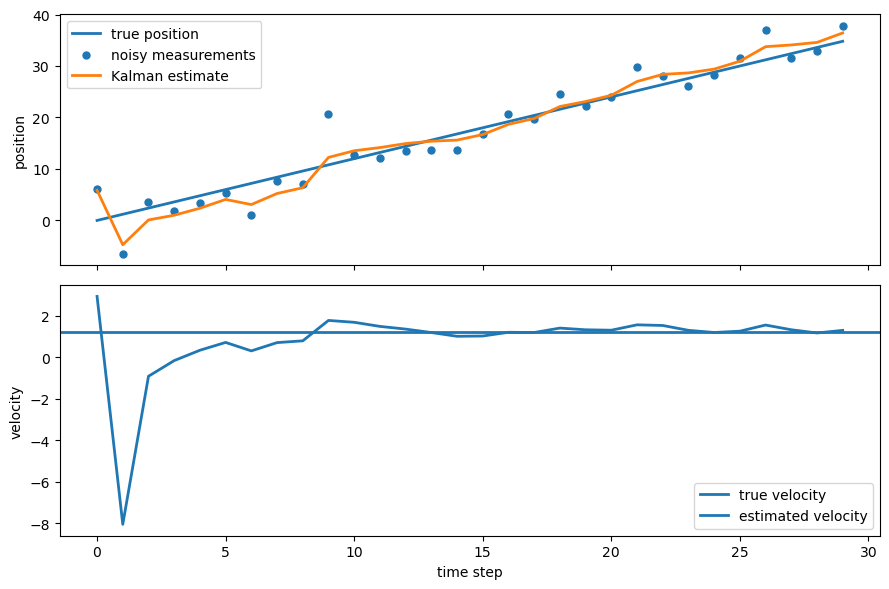

In [5]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

    axes[0].plot(times, true_positions, label="true position", linewidth=2)
    axes[0].scatter(times, measurements, label="noisy measurements", s=25)
    axes[0].plot(times, position_estimates, label="Kalman estimate", linewidth=2)
    axes[0].set_ylabel("position")
    axes[0].legend()

    axes[1].axhline(true_velocity, label="true velocity", linewidth=2)
    axes[1].plot(times, velocity_estimates, label="estimated velocity", linewidth=2)
    axes[1].set_xlabel("time step")
    axes[1].set_ylabel("velocity")
    axes[1].legend()

    fig.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib is not installed, so the plot is skipped.")

## 8. How to choose $Q$ and $R$

$R$ describes measurement noise. If you know the sensor standard deviation, use variance: $R = \sigma_z^2$ for a scalar measurement.

$Q$ describes process noise. It controls how much the filter allows the state to deviate from the process model.

- Larger $Q$: the filter adapts faster, but estimates are noisier.
- Smaller $Q$: the filter is smoother, but may lag behind real changes.
- Larger $R$: the filter trusts measurements less.
- Smaller $R$: the filter trusts measurements more.

In practice, tuning $Q$ and $R$ is often the most important part of using a Kalman filter well.

## 9. Common mistakes

- Using the wrong state vector. Include quantities needed to make the dynamics simple, such as velocity when tracking position.
- Making $Q$ too small. The filter can become overconfident and stop adapting.
- Making $R$ too small. The filter can chase measurement noise.
- Mixing shapes. Treat state and measurement values as vectors, even for scalar examples.
- Inverting matrices directly. Use `np.linalg.solve` where possible for better numerical behavior.

For nonlinear systems, use an Extended Kalman Filter, Unscented Kalman Filter, or particle filter instead of the basic linear Kalman filter.

## 10. Small exercises

Try changing these values and rerunning the examples:

1. Increase `measurement_std` in Example 2. The filter should rely more on the model.
2. Increase `Q` in Example 2. The velocity estimate should adapt faster but become noisier.
3. Change the true motion so velocity slowly increases. Then increase process noise to let the filter follow the acceleration.
4. Add acceleration to the state vector: `[position, velocity, acceleration]`.